In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

In [3]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

In [4]:
excitatory_type = "ss4"
inhibitory_type = "b"

In [5]:
seed = 1234

## Get params from file

In [6]:
path = "cmaes_spatial_ei_run8/best_result.json"
# Import as dict
import json
with open(path, "r") as f:
    z = json.load(f)

In [7]:
z["params"]

{'distance_scale': 20.75282632347198,
 'lambda_E': 0.33125465967642215,
 'lambda_I': 0.4060348312758674,
 'mu_E': 65.85333119212532,
 'mu_I': 34.70964887423673,
 'normalize_target_out_E': 88.52644399474119,
 'normalize_target_out_I': 976.7365737215496,
 'outdeg_b_dist': 'neg-bin',
 'outdeg_b_param1': 115.59520354960809,
 'outdeg_b_param2': 60.5433193285639,
 'outdeg_ss4_dist': 'lognormal',
 'outdeg_ss4_param1': 2.1954800982285794,
 'outdeg_ss4_param2': 0.2685231236184909,
 'p0_EE': 0.24901807749759927,
 'p0_EI': 0.7067475103114069,
 'p0_IE': 0.7582523042568522,
 'p0_II': 0.1146677551393086,
 'sigma_E': 0.9129338034163748,
 'sigma_I': 37.77497087709109,
 'type_fraction_b': 0.28308114450792843,
 'type_fraction_ss4': 0.7169188554920716,
 'weight_dist_b': 'normal',
 'weight_dist_ss4': 'normal'}

In [8]:
z["params"]
distance_scale = z["params"]["distance_scale"]
lambda_E = z["params"]["lambda_E"]
lambda_I = z["params"]["lambda_I"]
mu_E = z["params"]["mu_E"]
mu_I = z["params"]["mu_I"]
normalize_target_out_E = z["params"]["normalize_target_out_E"]
normalize_target_out_I = z["params"]["normalize_target_out_I"]
outdeg_b_dist = z["params"]["outdeg_b_dist"]
outdeg_b_param1 = z["params"]["outdeg_b_param1"]
outdeg_b_param2 = z["params"]["outdeg_b_param2"]
outdeg_ss4_dist = z["params"]["outdeg_ss4_dist"]
outdeg_ss4_param1 = z["params"]["outdeg_ss4_param1"]
outdeg_ss4_param2 = z["params"]["outdeg_ss4_param2"]
p0_EE = z["params"]["p0_EE"]
p0_EI = z["params"]["p0_EI"]
p0_IE = z["params"]["p0_IE"]
p0_II = z["params"]["p0_II"]
sigma_E = z["params"]["sigma_E"]
sigma_I = z["params"]["sigma_I"]
type_fraction_b = z["params"]["type_fraction_b"]
type_fraction_ss4 = z["params"]["type_fraction_ss4"]
weight_dist_b = z["params"]["weight_dist_b"]
weight_dist_ss4 = z["params"]["weight_dist_ss4"]

## Generate network

In [9]:
n_neurons = 150

In [10]:
type_fractions = {
    "ss4": type_fraction_ss4,
    "b": type_fraction_b,
}

inhibitory_types = ("b")

p0_by_pair = {"EE": p0_EE, "EI": p0_EI, "IE": p0_IE, "II": p0_II}

lambda_by_preclass = {"E": lambda_E, "I": lambda_I} # Distance factor

weight_dist_by_ntype={"ss4": weight_dist_ss4, "b": weight_dist_b}

outdegree_config_by_type={
        # lognormal: params = (mu, sigma), then k = floor(exp(N(mu,sigma)))
        "ss4": {"dist": outdeg_ss4_dist, "params": (outdeg_ss4_param1, outdeg_ss4_param2)},
        "b":   {"dist": outdeg_b_dist, "params": (outdeg_b_param1, outdeg_b_param2)},
    }

normalize_mode = "out"
normalize_target_out_E = normalize_target_out_E
normalize_target_out_I = normalize_target_out_I

G = generate_spatial_ei_network(n_neurons=n_neurons, type_fractions=type_fractions,
                                inhibitory_types=inhibitory_types,
                                mu_E=mu_E, sigma_E=sigma_E, mu_I=mu_I, sigma_I=sigma_I,
                                p0_by_pair=p0_by_pair,
                                lambda_by_preclass=lambda_by_preclass,
                                distance_scale=distance_scale,
                                weight_dist_by_ntype=weight_dist_by_ntype,
                                outdegree_config_by_type=outdegree_config_by_type,
                                normalize_mode=normalize_mode,
                                normalize_target_out_E=normalize_target_out_E,
                                normalize_target_out_I=normalize_target_out_I,)

In [11]:
# type_fractions = {
#     "ss4": 0.8,
#     "b": 0.2,
# }

# inhibitory_types = ("b")

# p0_by_pair = {"EE": 0.5, "EI": 0.5, "IE": 0.5, "II": 0.5}

# lambda_by_preclass = {"E": 0.2, "I": 0.05} # Distance factor

# weight_dist_by_ntype={"ss4": "lognormal", "b": "normal"}

# outdegree_config_by_type={
#         # lognormal: params = (mu, sigma), then k = floor(exp(N(mu,sigma)))
#         "ss4": {"dist": "lognormal", "params": (2.65, 0.8)},
#         "b":   {"dist": "neg-bin", "params": (50, 40)},
#     }

# normalize_mode = "out"
# # normalize_target_out_E = 25.0
# # normalize_target_out_I = 1000.0

# normalize_target_out_E = 5.0
# normalize_target_out_I = 800.0

# G = generate_spatial_ei_network(n_neurons=n_neurons, type_fractions=type_fractions,
#                                 inhibitory_types=inhibitory_types,
#                                 mu_E=0.0, sigma_E=1.6, mu_I=30.0, sigma_I=6.0,
#                                 p0_by_pair=p0_by_pair,
#                                 lambda_by_preclass=lambda_by_preclass,
#                                 distance_scale=20.0,
#                                 weight_dist_by_ntype=weight_dist_by_ntype,
#                                 outdegree_config_by_type=outdegree_config_by_type,
#                                 normalize_mode=normalize_mode,
#                                 normalize_target_out_E=normalize_target_out_E,
#                                 normalize_target_out_I=normalize_target_out_I,)

In [12]:
# Add compartment="in" to all nodes
for n in G.nodes:
    G.nodes[n]['compartment'] = 'in'

Text(0.5, 1.0, 'b Weight Distribution after Lognormal Redistribution')

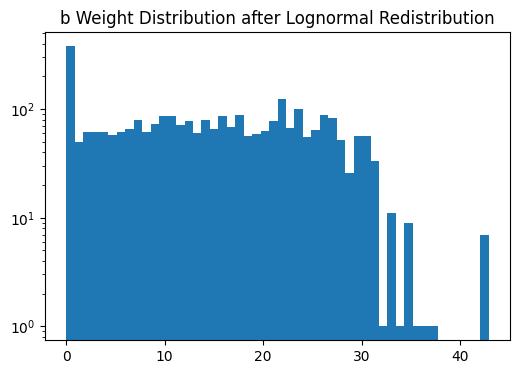

In [13]:
# Plot ss4 weight distribution
n_test_type = "b"
weights = [G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['ntype'] == n_test_type]
plt.figure(figsize=(6,4))
plt.hist(weights, bins=50, log=True)
plt.title(f"{n_test_type} Weight Distribution after Lognormal Redistribution")

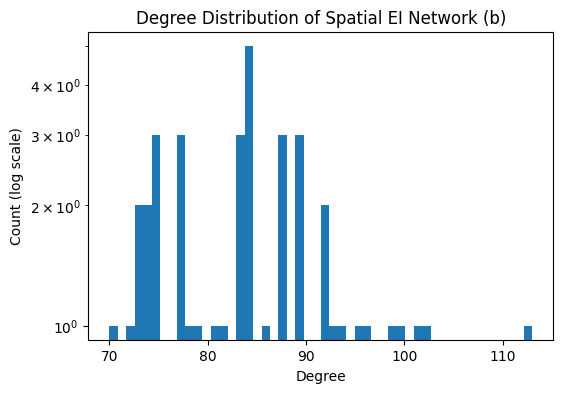

In [14]:
# Plot degree distribution
n_type_show = "b"
degrees = [G.degree(n) for n in G.nodes() if G.nodes[n]['ntype'] == n_type_show]
plt.figure(figsize=(6,4))
plt.hist(degrees, bins=50, log=True)
plt.title(f"Degree Distribution of Spatial EI Network ({n_type_show})")
plt.xlabel("Degree")
plt.ylabel("Count (log scale)")
plt.show()

In [15]:
enable_plot = False

if enable_plot:
    # Plot graph G using "pos" attribute for node positions
    pos = nx.get_node_attributes(G, 'pos')
    # Edge thinckness proportional to weight
    edges = G.edges()
    weights = [G[u][v]['weight'] / 100.0 for u, v in edges]
    # Node size proportional to degree
    degrees = [G.degree(n) for n in G.nodes()]
    # Node color by neuron type
    ntypes = nx.get_node_attributes(G, 'ntype')
    # Map neuron types to colors
    color_map = {'ss4': 'blue', 'b': 'red'}
    node_colors = [color_map.get(ntypes[n], 'gray') for n in G.nodes()]
    # Edge alpha
    alphas = [0.2 + 0.8 * G[u][v]['weight'] / 10.0 for u, v in edges]
    plt.figure(figsize=(8,8))
    nx.draw(G, pos, node_size=degrees, width=weights, edge_cmap=plt.cm.viridis, node_color=node_colors, alpha=0.65, with_labels=False)
    plt.title("Spatial EI Network Visualization")
    plt.show()

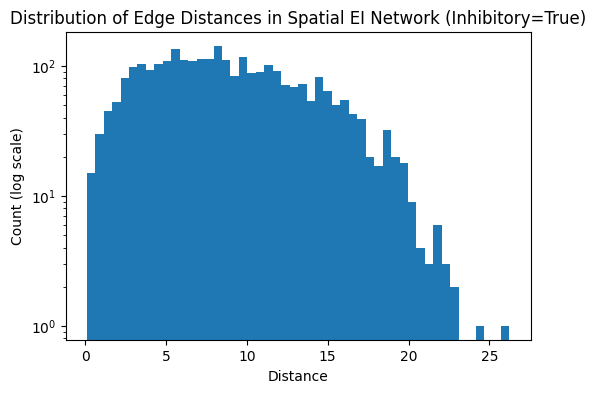

In [16]:
# Print distribution of "distance" attribute for edges
if_inhibitory = True
distances = [G[u][v]['distance'] for u, v in G.edges() if G.nodes[u]['inhibitory'] == if_inhibitory]
plt.figure(figsize=(6,4))
plt.hist(distances, bins=50, log=True)
plt.title(f"Distribution of Edge Distances in Spatial EI Network (Inhibitory={if_inhibitory})")
plt.xlabel("Distance")
plt.ylabel("Count (log scale)")
plt.show()

## Simulation setup

In [17]:
dt = 0.1

In [18]:
# Neuron population parameters
n_neurons = G.number_of_nodes()
neuron_types = [excitatory_type, inhibitory_type]
n_neuron_types = len(neuron_types)
inhibitory = [False, True]
threshold_decay = np.exp(-dt / 5)

pop = NeuronPopulation(n_neurons, neuron_types, inhibitory, threshold_decay)

In [19]:
# Connectome
# Max number of outgoing synapses per neuron
max_synapses = max(dict(G.out_degree()).values())

connectome = Connectome(max_synapses, pop)

connectome.nx_to_connectome(G)

In [20]:
nmda_weight = np.ones(connectome.neuron_population.n_neurons, dtype=float)
nmda_weight[pop.inhibitory_mask.astype(bool)] = 0.959685703507305 * 0.5
# Invert to make excitatory neurons have NMDA weight 1, inhibitory 0
# nmda_weight

In [21]:
# connectome.compute_metrics(small_world=False)

### Simulation function

In [22]:
def sim_w_input(sim, sim_len_ms, input_mask, input_rate, input_amp):
    poisson = PoissonInput(n_neurons, rate=input_rate * input_mask, amplitude=input_amp)
    steps = int(sim_len_ms / dt)
    for _ in tqdm(range(steps)):
        sim.step(spike_ext=poisson(dt), reward=1.0)

### Plastic mask

In [23]:
# out_degrees = dict(G.out_degree())
# top_neurons_plastic = sorted(out_degrees, key=out_degrees.get, reverse=True)
node_list = list(G.nodes())
# Shuffle node list
random.shuffle(node_list)
compartment_out_neurons = [n for n in node_list if G.nodes[n]['ntype'] == 'ss4']
p = 0.2
top_neurons_plastic = compartment_out_neurons[:int(p * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
random.shuffle(top_neurons_plastic)
length_top_neurons_plastic = len(top_neurons_plastic)
print(f"Top {p*100}% of excitatory neurons by out-degree for plasticity: {length_top_neurons_plastic} neurons")
# Check compartment distribution of top neurons
compartment_counts = Counter(G.nodes[n]['compartment'] for n in top_neurons_plastic)
print("Compartment distribution among top neurons:")
for compartment, count in compartment_counts.items():
    print(f"  {compartment}: {count} neurons")

plastic_mask = np.isin(np.arange(n_neurons), top_neurons_plastic)

Top 20.0% of excitatory neurons by out-degree for plasticity: 21 neurons
Compartment distribution among top neurons:
  in: 21 neurons


### Output config

In [24]:
# Choose top 20 % of neurons by out-degree in compartment "out"
# out_degrees = dict(G.out_degree())
# top_neurons_out = sorted(out_degrees, key=out_degrees.get, reverse=True)
compartment_out_neurons = [n for n in G.nodes if G.nodes[n]['ntype'] == 'ss4']
p_out = 1.0
top_neurons_out = compartment_out_neurons[:int(p_out * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
# random.shuffle(top_neurons_out)
## Sort by position y coordinate
top_neurons_out.sort(key=lambda n: G.nodes[n]['pos'][1])
length_top_neurons_out = len(top_neurons_out)
print(f"Top {p_out*100}% of excitatory neurons by out-degree in 'out' compartment: {length_top_neurons_out} neurons")
# Check neuron types of top neurons
top_neuron_types = [G.nodes[n]['ntype'] for n in top_neurons_out]
type_counts = Counter(top_neuron_types)
print("Neuron type distribution among top neurons:")
for ntype, count in type_counts.items():
    print(f"  {ntype}: {count} neurons")

Top 100.0% of excitatory neurons by out-degree in 'out' compartment: 108 neurons
Neuron type distribution among top neurons:
  ss4: 108 neurons


In [25]:
# Top half of output neurons
out_1 = top_neurons_out[:len(top_neurons_out) // 2]
out_2 = top_neurons_out[len(top_neurons_out) // 2:]

# Weight sum of connections within out_1, within out_2, and between out_1 and out_2
weight_out_1_to_out_1 = sum(G[u][v]['weight'] for u in out_1 for v in out_1 if G.has_edge(u, v))
weight_out_2_to_out_2 = sum(G[u][v]['weight'] for u in out_2 for v in out_2 if G.has_edge(u, v))
weight_out_1_to_out_2 = sum(G[u][v]['weight'] for u in out_1 for v in out_2 if G.has_edge(u, v))
print(f"Total weight from out_1 to out_1: {weight_out_1_to_out_1:.2f}")
print(f"Total weight from out_2 to out_2: {weight_out_2_to_out_2:.2f}")
print(f"Total weight from out_1 to out_2: {weight_out_1_to_out_2:.2f}")

Total weight from out_1 to out_1: 1452.27
Total weight from out_2 to out_2: 1404.92
Total weight from out_1 to out_2: 942.19


### Input config

In [26]:
# Choose top 20 % of neurons by out-degree in compartment "in"
# out_degrees = dict(G.out_degree())
# top_neurons_in = sorted(out_degrees, key=out_degrees.get, reverse=True)
neuron_list = list(G.nodes())
# Shuffle node list
random.shuffle(neuron_list)
compartment_out_neurons = [n for n in neuron_list if G.nodes[n]['ntype'] == 'ss4']
p = 0.2
top_neurons_in = compartment_out_neurons[:int(p * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
random.shuffle(top_neurons_in)
length_top_neurons_in = len(top_neurons_in)
print(f"Random {p*100}% of excitatory neurons (in-neurons): {length_top_neurons_in} neurons")
# Check neuron types of top neurons
top_neuron_types = [G.nodes[n]['ntype'] for n in top_neurons_in]
type_counts = Counter(top_neuron_types)
print("Neuron type distribution among top neurons:")
for ntype, count in type_counts.items():
    print(f"  {ntype}: {count} neurons")
input_neurons_1 = top_neurons_in[int(0.5 * len(top_neurons_in)):]
input_neurons_2 = top_neurons_in[:int(0.5 * len(top_neurons_in))]

input_1_mask = np.zeros(n_neurons, dtype=bool)
input_2_mask = np.zeros(n_neurons, dtype=bool)

input_1_mask[input_neurons_1] = True
input_2_mask[input_neurons_2] = True

Random 20.0% of excitatory neurons (in-neurons): 21 neurons
Neuron type distribution among top neurons:
  ss4: 21 neurons


### Resting potentials

In [27]:
resting_potentials = np.zeros(n_neurons)

for i in range(n_neurons):
    resting_potentials[i] = neuron_type_IZ[G.nodes[i]["ntype"]][5]

## Test simulation

100%|██████████| 4000/4000 [00:01<00:00, 3298.74it/s]


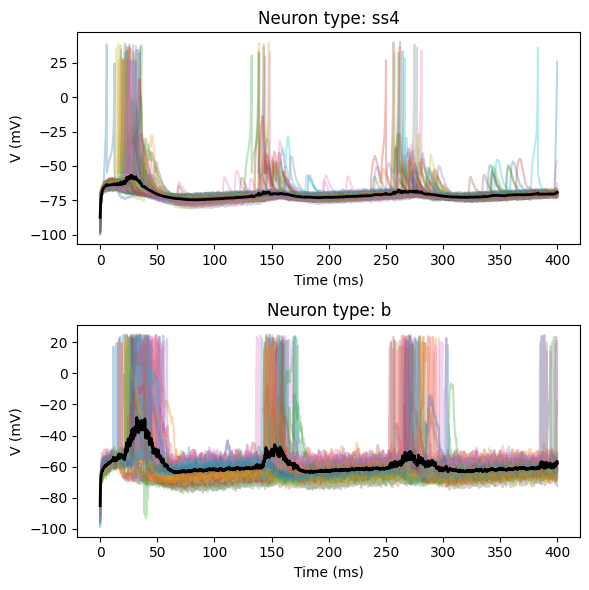

c:\Users\kingt\anaconda3\envs\neuro\Lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kingt\anaconda3\envs\neuro\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\kingt\Dropbox\Programming\NeuralSimV3\NeuroSimV3\python\src\overhead.py:175: RuntimeWarning: invalid value encountered in divide
  fanos = np.where(mu > 0, var / mu, np.nan)


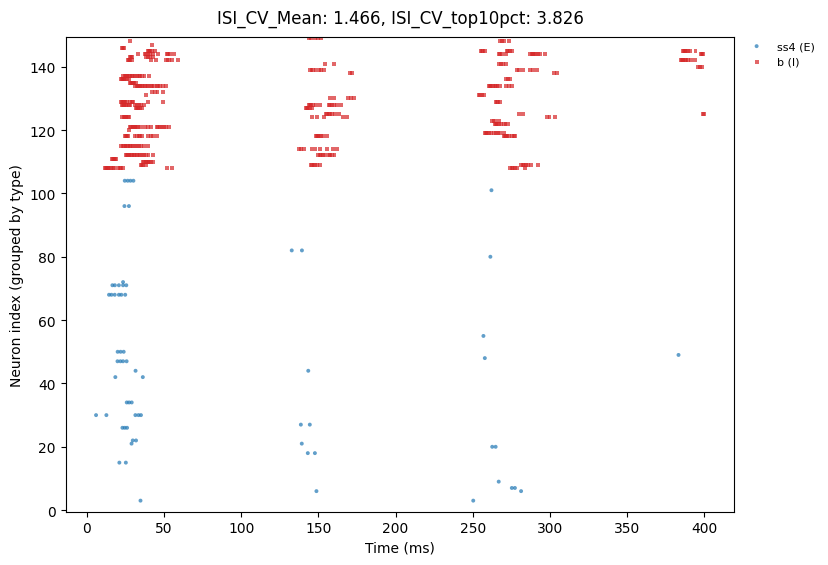

In [28]:
# Randomize initial voltages
Vs = rng.uniform(-100, -70, size=n_neurons)
us = rng.uniform(0, 400, size=n_neurons)
spikes = np.zeros(n_neurons, dtype=bool)
Ts = np.zeros_like(spikes, dtype=float)

state0 = (Vs,
          us,
          spikes.copy(),
          Ts.copy())


sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
                synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
                enable_debug_logger=False,
                enable_plasticity=False, plasticity="clopath", plasticity_reward_type="online",
                plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
                                    "max_weight": 100.0, "weight_update_scale": 0.1,
                                    # "enable_debug_logger": False, 
                                    "theta_minus": resting_potentials + 5.0,
                                    "theta_plus": resting_potentials + 15.0
                                    })

sim.configure_output_readout(output_neuron_indices=top_neurons_out, output_dim=len(top_neurons_out), rate_window_ms=250.0,
                            enable_logger=True)

amplitude = 5.0
v_ext = 5.0

out_neurons_1 = sim.output_readout["groups"][0]
out_neurons_2 = sim.output_readout["groups"][1]

# Append input_neurons_1 and out_neurons_1 to the same list
input_neurons_1_and_out_1 = np.concatenate((input_neurons_1, out_neurons_1))
input_neurons_2_and_out_2 = np.concatenate((input_neurons_2, out_neurons_2))

i1o1 = np.zeros(n_neurons, dtype=bool)
i1o1[input_neurons_1_and_out_1] = True
i2o2 = np.zeros(n_neurons, dtype=bool)
i2o2[input_neurons_2_and_out_2] = True

i1 = np.zeros(n_neurons, dtype=bool)
i1[input_neurons_1] = True
i2 = np.zeros(n_neurons, dtype=bool)
i2[input_neurons_2] = True

i1i2 = np.zeros(n_neurons, dtype=bool)
i1i2[input_neurons_1_and_out_1] = True
i1i2[input_neurons_2_and_out_2] = True

v_ext_mult = (1.0, 1.0)

i1_rate = v_ext * i1 * v_ext_mult[0]
i2_rate = v_ext * i2 * v_ext_mult[1]

i1i2_rate = i1_rate + i2_rate

sim_w_input(sim, sim_len_ms=400.0, input_mask=i1i2, input_rate=i1i2_rate, input_amp=amplitude)

rates = np.array(sim.output_logger)[-1,:]
rates = rates / np.linalg.norm(rates)

sim.plot_voltage_per_type(figsize=(6, 6))

stats = sim.stats.compute_metrics(dt, bin_ms_participation=300)

isi_mean = stats['ISI_CV_mean']
isi_top = stats["ISI_CV_mean_top10pct"]

sim.plot_spike_raster(figsize=(10, 6), title=f"ISI_CV_Mean: {isi_mean:.3f}, ISI_CV_top10pct: {isi_top:.3f}", t_start_ms=0.0, t_stop_ms=9000.0)

## XOR Simulation

In [29]:
# Randomize initial voltages
Vs = rng.uniform(-100, -70, size=n_neurons)
us = rng.uniform(0, 400, size=n_neurons)
spikes = np.zeros(n_neurons, dtype=bool)
Ts = np.zeros_like(spikes, dtype=float)

state0 = (Vs,
          us,
          spikes.copy(),
          Ts.copy())

n_examples = 10
v_ext_mults = [(1.0, 1.0), (1.0, 20.0), (20.0, 1.0), (20.0, 20.0)]

for v_ext_mult in v_ext_mults:
    outs = []
    for _ in range(n_examples):

        sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
                        synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
                        enable_debug_logger=False,
                        enable_plasticity=False, plasticity="clopath", plasticity_reward_type="online",
                        plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
                                            "max_weight": 100.0, "weight_update_scale": 0.1,
                                            # "enable_debug_logger": False, 
                                            "theta_minus": resting_potentials + 5.0,
                                            "theta_plus": resting_potentials + 15.0
                                            })

        sim.configure_output_readout(output_neuron_indices=top_neurons_out, output_dim=len(top_neurons_out), rate_window_ms=250.0,
                                    enable_logger=True)

        amplitude = 5
        v_ext = 5.0

        out_neurons_1 = sim.output_readout["groups"][0]
        out_neurons_2 = sim.output_readout["groups"][1]

        # Append input_neurons_1 and out_neurons_1 to the same list
        input_neurons_1_and_out_1 = np.concatenate((input_neurons_1, out_neurons_1))
        input_neurons_2_and_out_2 = np.concatenate((input_neurons_2, out_neurons_2))

        i1o1 = np.zeros(n_neurons, dtype=bool)
        i1o1[input_neurons_1_and_out_1] = True
        i2o2 = np.zeros(n_neurons, dtype=bool)
        i2o2[input_neurons_2_and_out_2] = True

        i1 = np.zeros(n_neurons, dtype=bool)
        i1[input_neurons_1] = True
        i2 = np.zeros(n_neurons, dtype=bool)
        i2[input_neurons_2] = True

        i1i2 = np.zeros(n_neurons, dtype=bool)
        i1i2[input_neurons_1_and_out_1] = True
        i1i2[input_neurons_2_and_out_2] = True

        i1_rate = v_ext * i1 * v_ext_mult[0]
        i2_rate = v_ext * i2 * v_ext_mult[1]

        i1i2_rate = i1_rate + i2_rate

        sim_w_input(sim, sim_len_ms=400.0, input_mask=i1i2, input_rate=i1i2_rate, input_amp=amplitude)

        rates = np.array(sim.output_logger)[-1,:]
        rates = rates / np.linalg.norm(rates)

        outs.append(rates)

    np.save(f"evo_result_7_{v_ext_mult[0]}_{v_ext_mult[1]}.npy", np.array(outs))

# sim.plot_voltage_per_type(figsize=(6, 6))

# stats = sim.stats.compute_metrics(dt, bin_ms_participation=300)

# isi_mean = stats['ISI_CV_mean']
# isi_top = stats["ISI_CV_mean_top10pct"]

# sim.plot_spike_raster(figsize=(10, 6), title=f"ISI_CV_Mean: {isi_mean:.3f}, ISI_CV_top10pct: {isi_top:.3f}", t_start_ms=0.0, t_stop_ms=9000.0)

100%|██████████| 4000/4000 [00:00<00:00, 4480.76it/s]


100%|██████████| 10000/10000 [00:00<00:00, 308259.64it/s]


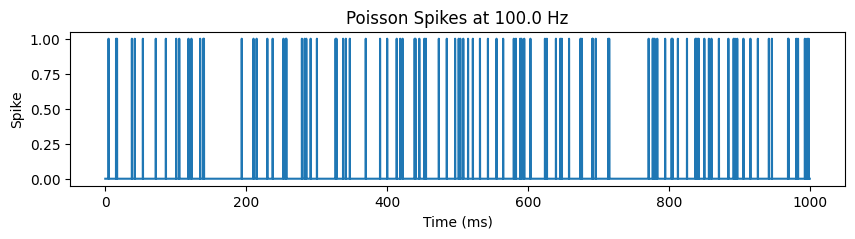

[110.]


In [30]:
# Plot poisson spikes over 1000 ms
rate = 100.0
poisson = PoissonInput(1, rate=rate, amplitude=1.0)
t_test = 1000.0
spikes = []
for t in tqdm(np.arange(0, t_test, dt)):
    spike = poisson(dt)
    spikes.append(spike)

# PLot
plt.figure(figsize=(10, 2))
plt.plot(np.arange(0, t_test, dt), spikes)
plt.title(f"Poisson Spikes at {rate} Hz")
plt.xlabel("Time (ms)")
plt.ylabel("Spike")
plt.show()

print(sum(spikes))


In [31]:
np.array(outs).shape

(10, 108)

C:\Users\kingt\AppData\Local\Temp\ipykernel_34968\146345256.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


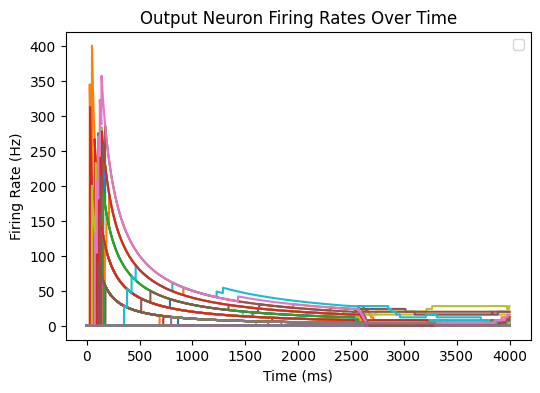

In [32]:
# Plot output
output_history = np.array(sim.output_logger)
plt.figure(figsize=(6,4))
plt.plot(output_history[:, :])
# plt.plot(output_history[:, 1], label="Output Neuron 2")
plt.title("Output Neuron Firing Rates Over Time")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.legend()
plt.show()

In [33]:
sim.stats.compute_metrics(dt, bin_ms_participation=300, t_start_ms=0, t_stop_ms=300.0)

{'rate_mean_Hz': 14.81728312784627,
 'rate_median_Hz': 3.3322225924691766,
 'rate_p95_Hz': 81.80606464511823,
 'rate_mean_Hz_E': 3.393930418255643,
 'rate_mean_Hz_I': 44.1916186667936,
 'rate_mean_Hz_E_active2spk': 12.634677329778961,
 'rate_mean_Hz_I_active2spk': 51.37176496723314,
 'ISI_CV_median': 1.7001843517545971,
 'ISI_CV_mean': 1.5992790976238953,
 'ISI_CV_mean_E': 0.7683971926157038,
 'ISI_CV_mean_I': 1.9658446439510389,
 'ISI_CV_mean_top10pct': 3.6411142953939617,
 'refractory_violations_per_neuron': 1.0933333333333333,
 'Fano_median_2ms': 0.999999999999998,
 'Fano_median_10ms': 1.9999999999999971,
 'Fano_median_50ms': 2.1199999999999997,
 'Fano_median_100ms': 2.0000000000000004,
 'Fano_median_300ms': 0.0,
 'Fano_median_500ms': 0.0,
 'Fano_median_1000ms': 0.0,
 'mean_noise_corr_2ms': 0.029911715241188377,
 'mean_noise_corr_10ms': 0.06492889585581042,
 'mean_noise_corr_50ms': 0.1018190440868985,
 'mean_noise_corr_100ms': 0.12045098525132905,
 'mean_noise_corr_300ms': 0.0,
 'me